<a href="https://colab.research.google.com/github/meenakshimeenuzz21/DSA-Class-Notes/blob/main/Final_CaseStudy_SupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [389]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

In [390]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
sample = pd.read_csv("/content/sample_submission.csv")


In [391]:
train.head()

,id,sexo,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,0J4_2016,H,174.18,106.85,80.19,52.43,30.20,23.26,88.74,51.0,95.7,104.2,208.4,2.38
1,A68_2016,H,171.12,104.59,79.45,51.14,30.61,24.04,90.22,50.5,94.4,102.2,204.4,2.14
2,E55_2015,H,174.69,106.83,82.14,49.09,30.60,26.47,91.42,52.7,96.6,105.2,210.4,2.50
3,7C7_2016,M,182.25,113.17,84.13,52.26,32.08,26.07,91.74,52.6,98.9,107.6,215.2,2.83
4,2C0_2018,H,173.70,105.19,80.37,49.20,34.00,27.12,87.77,50.8,94.5,103.7,207.4,2.73


In [392]:
test.head()

,id,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
0,A70_2018,183.57,117.18,87.90,53.60,33.10,26.50,95.70,52.5,98.6,104.4,208.8,3.35
1,5C9_2018,166.60,105.05,80.63,51.64,31.31,26.10,88.82,50.7,93.4,101.4,202.8,2.43
2,5E1_2018,175.53,111.23,84.93,53.74,32.75,24.93,91.42,51.3,94.2,103.4,206.8,2.99
3,C58_2018,187.85,116.90,87.52,54.22,35.10,27.00,99.48,52.3,99.8,107.6,215.2,3.55
4,5E2_2018,182.67,116.40,87.24,54.57,33.59,25.40,96.43,53.4,100.3,110.1,220.2,3.06


In [393]:
train.shape

(94, 14)

In [394]:
test.shape

(41, 13)

In [395]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                94 non-null     object 
 1   sexo              94 non-null     object 
 2   longitudCraneo    94 non-null     float64
 3   longitudPico      94 non-null     float64
 4   longitudNarina    94 non-null     float64
 5   anchoCraneo       94 non-null     float64
 6   altoPico          94 non-null     float64
 7   anchoPico         94 non-null     float64
 8   tarso             94 non-null     float64
 9   longAlaCerrada    94 non-null     float64
 10  longAlaAbierta    94 non-null     float64
 11  mediaEnvergadura  94 non-null     float64
 12  envergadura       94 non-null     float64
 13  peso              93 non-null     float64
dtypes: float64(12), object(2)
memory usage: 10.4+ KB


In [396]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                41 non-null     object 
 1   longitudCraneo    41 non-null     float64
 2   longitudPico      41 non-null     float64
 3   longitudNarina    41 non-null     float64
 4   anchoCraneo       41 non-null     float64
 5   altoPico          41 non-null     float64
 6   anchoPico         41 non-null     float64
 7   tarso             41 non-null     float64
 8   longAlaCerrada    41 non-null     float64
 9   longAlaAbierta    41 non-null     float64
 10  mediaEnvergadura  41 non-null     float64
 11  envergadura       41 non-null     float64
 12  peso              41 non-null     float64
dtypes: float64(12), object(1)
memory usage: 4.3+ KB


In [397]:
train.describe()

,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
count,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.00000,94.000000,94.000000,94.000000,94.000000,93.000000
mean,176.580106,110.130426,82.936383,52.687553,32.535000,25.425319,90.88766,51.667021,96.259043,104.765213,209.530426,2.624516
std,5.443278,4.028920,3.187515,2.226749,1.383418,1.439065,2.85098,1.185340,2.187660,2.486498,4.972997,0.315968
min,165.580000,102.710000,74.820000,46.500000,29.340000,21.480000,84.04000,48.700000,88.900000,99.300000,198.600000,2.030000
25%,172.187500,106.835000,80.217500,51.207500,31.605000,24.500000,88.66000,51.000000,94.725000,103.175000,206.350000,2.400000
50%,176.915000,110.070000,83.325000,52.475000,32.605000,25.480000,91.03500,51.600000,96.500000,104.950000,209.900000,2.600000
75%,180.525000,113.252500,85.425000,54.347500,33.460000,26.372500,92.57000,52.475000,97.875000,106.550000,213.100000,2.830000
max,191.210000,119.480000,90.680000,58.360000,35.500000,28.700000,99.69000,54.700000,101.300000,112.200000,224.400000,3.530000


In [398]:
test.describe()

,longitudCraneo,longitudPico,longitudNarina,anchoCraneo,altoPico,anchoPico,tarso,longAlaCerrada,longAlaAbierta,mediaEnvergadura,envergadura,peso
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,178.985366,111.062195,83.825366,53.016585,33.127805,26.038049,91.924146,51.726829,96.824390,105.373171,210.746341,2.632439
std,6.031885,4.588698,3.556708,2.114764,1.235426,1.134143,3.190172,1.261750,2.558298,2.692678,5.385355,0.429318
min,166.600000,100.810000,75.230000,48.690000,28.850000,23.360000,83.180000,49.400000,91.400000,99.900000,199.800000,2.050000
25%,174.770000,107.690000,81.220000,51.730000,32.570000,25.400000,89.750000,50.700000,95.100000,103.800000,207.600000,2.300000
50%,178.830000,111.400000,83.860000,53.190000,33.020000,26.010000,91.370000,51.500000,96.800000,105.300000,210.600000,2.550000
75%,182.670000,115.440000,87.240000,54.310000,33.950000,26.840000,94.150000,52.800000,98.800000,107.600000,215.200000,2.990000
max,193.220000,117.440000,90.330000,57.330000,35.120000,28.350000,99.480000,54.100000,102.000000,110.100000,220.200000,3.680000


In [399]:
train.columns.tolist()

['id',
 'sexo',
 'longitudCraneo',
 'longitudPico',
 'longitudNarina',
 'anchoCraneo',
 'altoPico',
 'anchoPico',
 'tarso',
 'longAlaCerrada',
 'longAlaAbierta',
 'mediaEnvergadura',
 'envergadura',
 'peso']

In [400]:
test.columns.tolist()

['id',
 'longitudCraneo',
 'longitudPico',
 'longitudNarina',
 'anchoCraneo',
 'altoPico',
 'anchoPico',
 'tarso',
 'longAlaCerrada',
 'longAlaAbierta',
 'mediaEnvergadura',
 'envergadura',
 'peso']

In [401]:
train.isnull().sum()

,0
id,0
sexo,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0


In [402]:
test.isnull().sum()

,0
id,0
longitudCraneo,0
longitudPico,0
longitudNarina,0
anchoCraneo,0
altoPico,0
anchoPico,0
tarso,0
longAlaCerrada,0
longAlaAbierta,0


In [403]:
train["sexo"].value_counts()

,count
sexo,
H,57
M,37


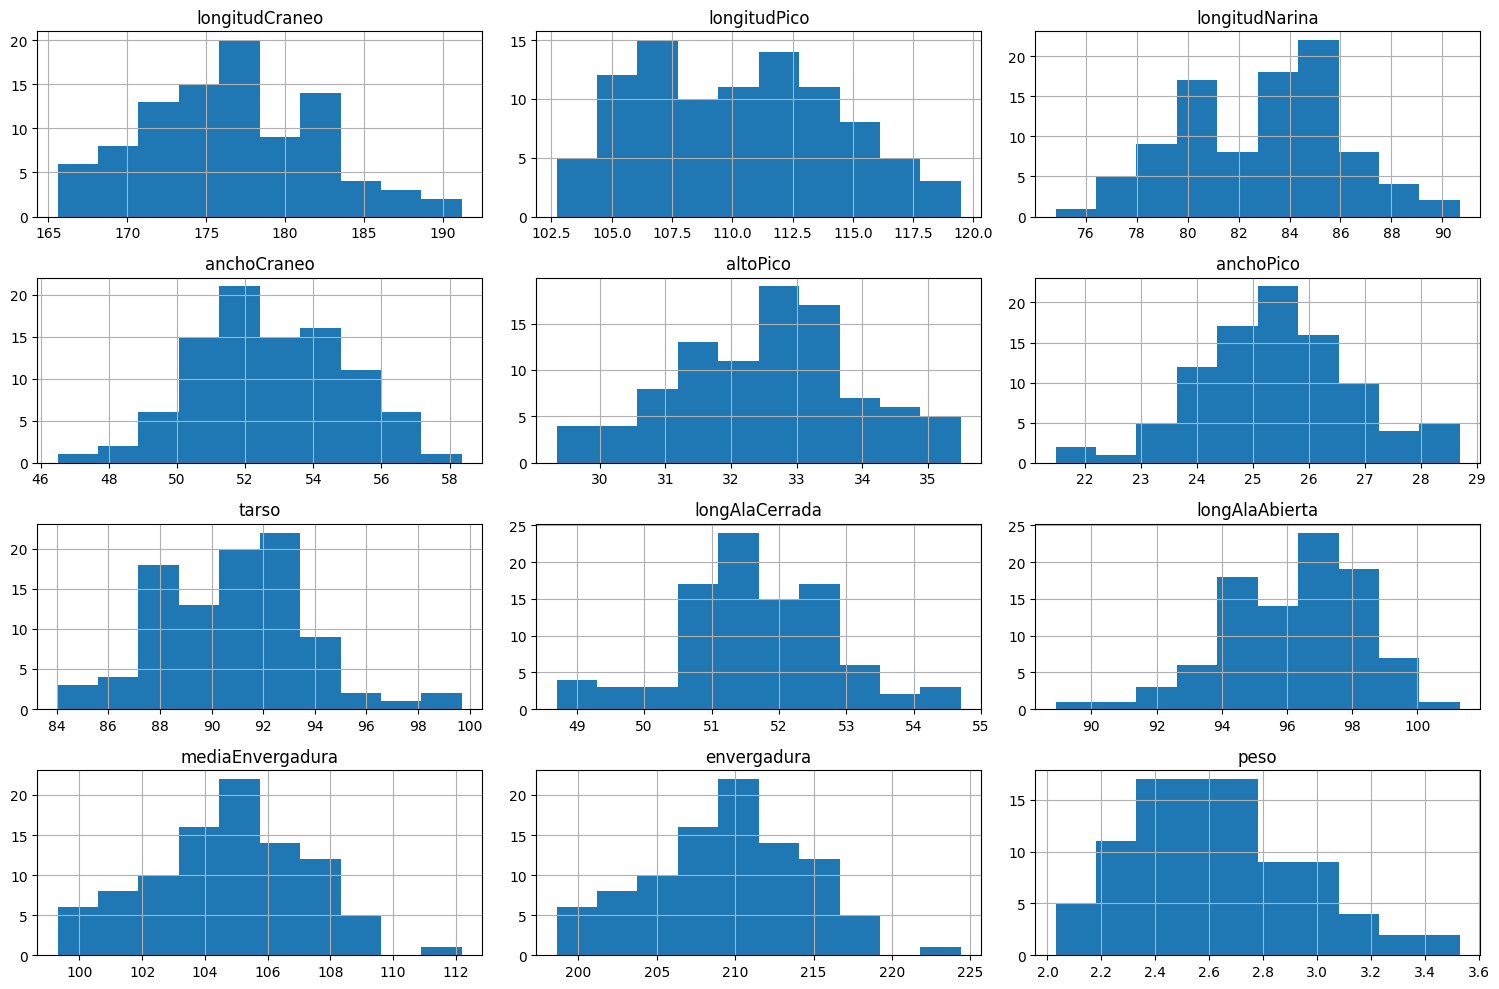

In [404]:
train.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

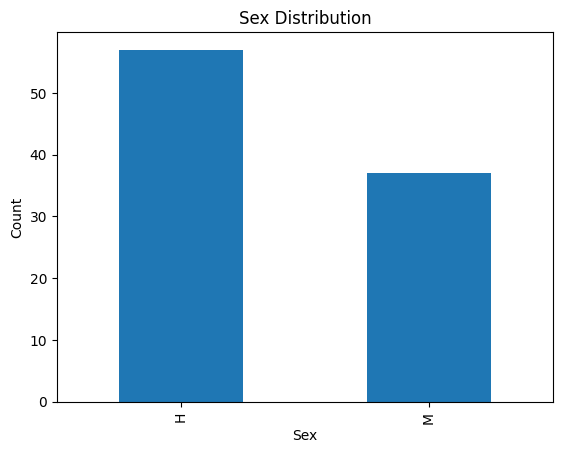

In [405]:
train["sexo"].value_counts().plot(kind="bar")

plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

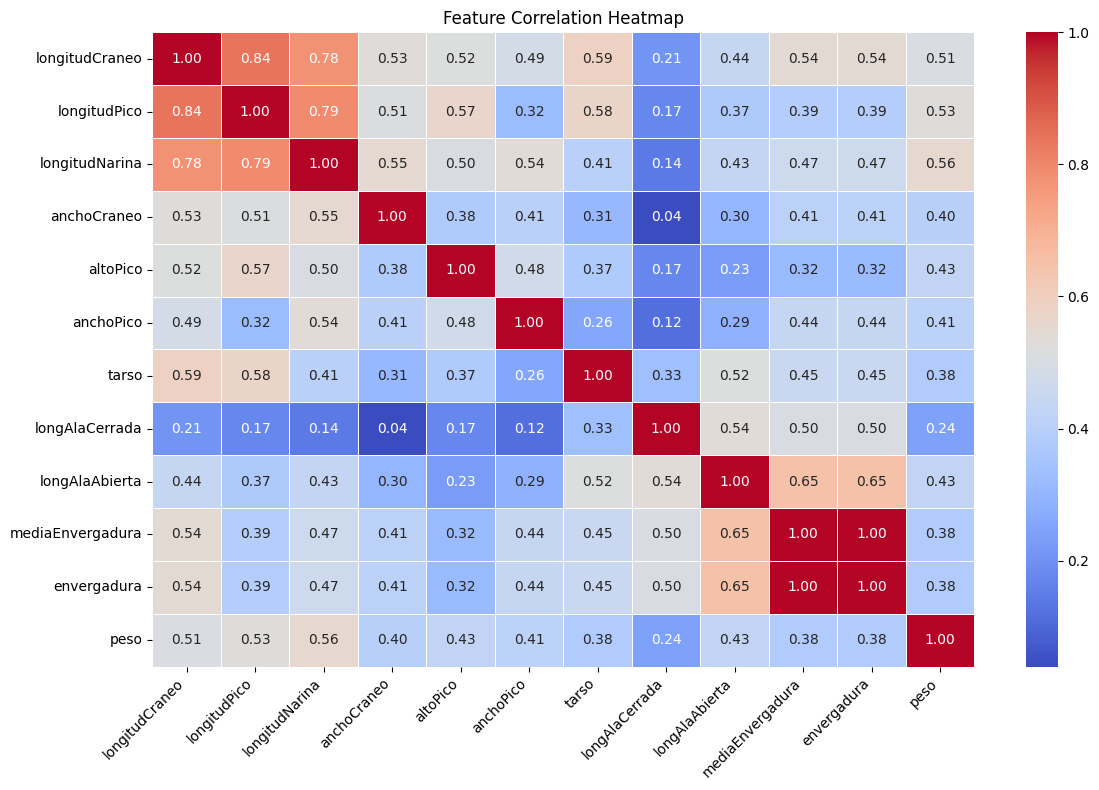

In [406]:
import seaborn as sns
correlation = train.drop(columns=["id", "sexo"]).corr()
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

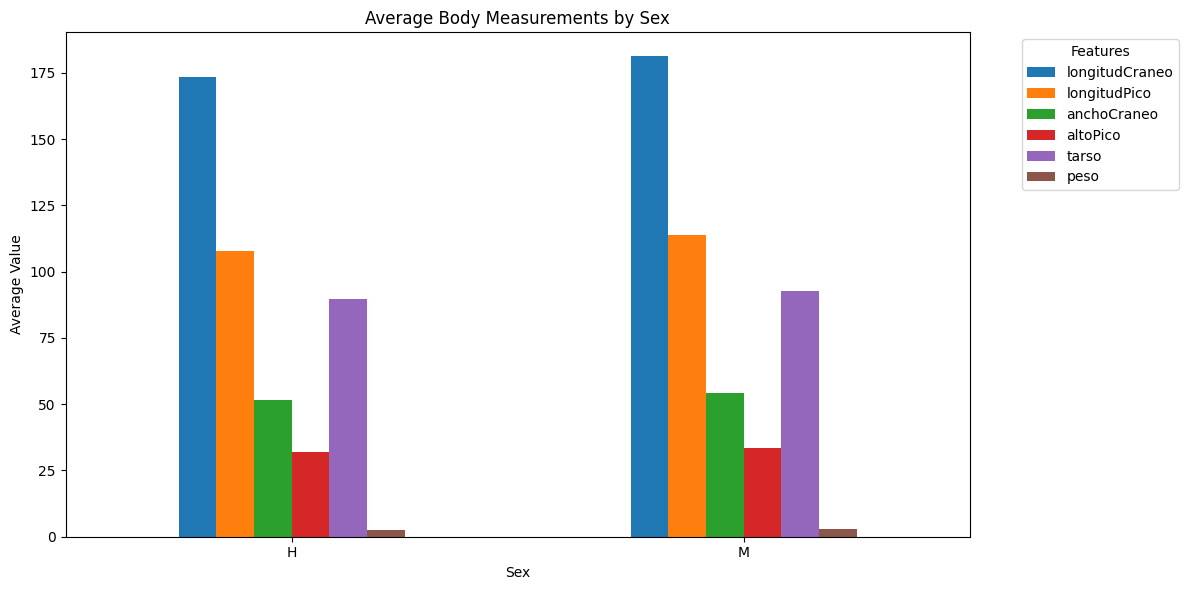

In [407]:
features = [
    "longitudCraneo",
    "longitudPico",
    "anchoCraneo",
    "altoPico",
    "tarso",
    "peso"
]

train.groupby("sexo")[features].mean().plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Body Measurements by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Features", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [408]:
X = train.drop(columns=["id", "sexo"])
y = train["sexo"]

X_test = test.drop(columns=["id"])

In [409]:
X.shape

(94, 12)

In [410]:
y.shape

(94,)

In [411]:
X_test.shape

(41, 12)

In [412]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=42)

In [413]:
X_train.shape

(75, 12)

In [414]:
X_val.shape

(19, 12)

In [415]:
y_train.shape

(75,)

In [416]:
y_val.shape

(19,)

In [417]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_val)

logistic_accuracy = accuracy_score(y_val, logistic_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.7894736842105263


In [418]:
svm_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(C=1, kernel="rbf"))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_val)

svm_accuracy = accuracy_score(y_val, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8421052631578947


In [419]:
print("Classification Report:")
print(classification_report(y_val, svm_pred))

Classification Report:
              precision    recall  f1-score   support

           H       0.89      0.80      0.84        10
           M       0.80      0.89      0.84         9

    accuracy                           0.84        19
   macro avg       0.84      0.84      0.84        19
weighted avg       0.85      0.84      0.84        19



In [420]:
svm_pred = svm_model.predict(X_val)
y_pred = svm_pred

In [421]:
cm = confusion_matrix(y_val, svm_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8 2]
 [1 8]]


In [422]:
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

rf_accuracy = accuracy_score(y_val, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7368421052631579


In [423]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

print("Model Performance:")
display(results)

Model Performance:


,Model,Accuracy
1,SVM,0.842105
0,Logistic Regression,0.789474
2,Random Forest,0.736842


In [424]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": logistic_model,
    "SVM": svm_model,
    "Random Forest": rf_model
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_results = pd.DataFrame(cv_results)
cv_results = cv_results.sort_values(
    by="Mean Accuracy",
    ascending=False
)

display(cv_results)

,Model,Mean Accuracy,Std
1,SVM,0.891813,0.093348
2,Random Forest,0.870760,0.101801
0,Logistic Regression,0.860234,0.076615


In [425]:
cv_scores = cross_val_score(
    svm_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.84210526 0.78947368 0.89473684 0.94736842 0.88888889]
Mean CV Accuracy: 0.8725146198830409


In [426]:
best_model = svm_model

best_model.fit(X, y)

print("Final model trained successfully!")
print("Selected Model: SVM")

Final model trained successfully!
Selected Model: SVM


In [427]:
test_predictions = best_model.predict(X_test)

print("Predictions for test data:")
print(test_predictions)

print("\nNumber of predictions:", len(test_predictions))

Predictions for test data:
['M' 'H' 'M' 'M' 'M' 'M' 'H' 'M' 'M' 'M' 'H' 'H' 'H' 'M' 'H' 'H' 'H' 'H'
 'H' 'H' 'H' 'H' 'H' 'M' 'M' 'H' 'H' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'H' 'H'
 'H' 'H' 'M' 'M' 'M']

Number of predictions: 41


In [428]:
submission = pd.DataFrame({
    "id": test["id"],
    "sexo": test_predictions})

print("Submission file:")
display(submission.head(10))

print("\nSubmission shape:", submission.shape)


Submission file:


,id,sexo
0,A70_2018,M
1,5C9_2018,H
2,5E1_2018,M
3,C58_2018,M
4,5E2_2018,M
5,5C2_2018,M
6,E21_2018,H
7,1C2_2018,M
8,C90_2018,M
9,A87_2018,M



Submission shape: (41, 2)


In [429]:
submission.to_csv("submission.csv", index= False)

print("submission.csv created successfully")

submission.csv created successfully
